In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

In [3]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [4]:
dataset_path = "brain_tumor_dataset"


In [5]:
train_path ="C:/Users/Ganesh/Downloads/archive (4)/Training"
test_path = "C:/Users/Ganesh/Downloads/archive (4)/Testing"


In [6]:
IMG_SIZE = 224
BATCH_SIZE = 32


In [7]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)


In [8]:
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)


Found 1596 images belonging to 2 classes.
Found 398 images belonging to 2 classes.


In [9]:
test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 1600 images belonging to 4 classes.


In [10]:
print("Classes:", train_data.class_indices)


Classes: {'glioma': 0, 'meningioma': 1}


In [11]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [12]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),

    Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.5),

    Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.5),

    Dense(train_data.num_classes, activation='softmax')
])

In [13]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,619,074 (9.99 MB)

 Trainable params: 361,090 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:



from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)



In [16]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5699 - loss: 1.4786
Epoch 1: val_accuracy improved from None to 0.75628, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.6046 - loss: 1.3677 - val_accuracy: 0.7563 - val_loss: 1.0468 - learning_rate: 1.0000e-04
Epoch 2/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7317 - loss: 1.1225
Epoch 2: val_accuracy improved from 0.75628 to 0.80905, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.7406 - loss: 1.0928 - val_accuracy: 0.8090 - val_loss: 0.9470 - learning_rate: 1.0000e-04
Epoch 3/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7592 - loss: 1.0598
Epoch 3: val_accuracy improved from 0.80905 to 0.86935, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.7619 - loss: 1.0508 - val_accuracy: 0.8693 - val_loss: 0.8823 - learning_rate: 1.0000e-04
Epoch 4/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7910 - loss: 0.9693
Epoch 4: val_accuracy did not improve from 0.86935
50/50 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.8170 - loss: 0.9399 - val_accuracy: 0.8668 - val_loss: 0.8398 - learning_rate: 1.0000e-04
Epoch 5/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8278 - loss: 0.9220
Epoch 5: val_accuracy improved from 0.86935 to 0.87688, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.8239 - loss: 0.9136 - val_accuracy: 0.8769 - val_loss: 0.7895 - learning_rate: 1.0000e-04
Epoch 6/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8366 - loss: 0.8959
Epoch 6: val_accuracy improved from 0.87688 to 0.87940, saving model to best_model.h5


...


Epoch 18: finished saving model to best_model.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8910 - loss: 0.6942 - val_accuracy: 0.9221 - val_loss: 0.6406 - learning_rate: 1.0000e-04
Epoch 19/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8854 - loss: 0.6817
Epoch 19: val_accuracy did not improve from 0.92211
50/50 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.8954 - loss: 0.6798 - val_accuracy: 0.9070 - val_loss: 0.6298 - learning_rate: 1.0000e-04
Epoch 20/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9027 - loss: 0.6550
Epoch 20: val_accuracy improved from 0.92211 to 0.92462, saving model to best_model.h5



Epoch 20: finished saving model to best_model.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.9010 - loss: 0.6597 - val_accuracy: 0.9246 - val_loss: 0.6342 - learning_rate: 1.0000e-04
Epoch 21/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9162 - loss: 0.6441
Epoch 21: val_accuracy did not improve from 0.92462
50/50 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.8985 - loss: 0.6669 - val_accuracy: 0.9246 - val_loss: 0.6101 - learning_rate: 1.0000e-04
Epoch 22/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8979 - loss: 0.6524
Epoch 22: val_accuracy improved from 0.92462 to 0.92714, saving model to best_model.h5



Epoch 22: finished saving model to best_model.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.8960 - loss: 0.6562 - val_accuracy: 0.9271 - val_loss: 0.6166 - learning_rate: 1.0000e-04
Epoch 23/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8862 - loss: 0.6644
Epoch 23: val_accuracy did not improve from 0.92714
50/50 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.8960 - loss: 0.6493 - val_accuracy: 0.9196 - val_loss: 0.6014 - learning_rate: 1.0000e-04
Epoch 24/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9097 - loss: 0.6311
Epoch 24: val_accuracy improved from 0.92714 to 0.92965, saving model to best_model.h5



Epoch 24: finished saving model to best_model.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.9085 - loss: 0.6266 - val_accuracy: 0.9296 - val_loss: 0.5853 - learning_rate: 1.0000e-04
Epoch 25/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9190 - loss: 0.6173
Epoch 25: val_accuracy improved from 0.92965 to 0.93467, saving model to best_model.h5



Epoch 25: finished saving model to best_model.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.9148 - loss: 0.6119 - val_accuracy: 0.9347 - val_loss: 0.5733 - learning_rate: 1.0000e-04


In [17]:
predictions = model.predict(test_data)
pred_classes = np.argmax(predictions, axis=1)

true_classes = test_data.classes
class_labels = list(test_data.class_indices.keys())


50/50 ━━━━━━━━━━━━━━━━━━━━ 42s 811ms/step


In [18]:
print("\nClassification Report:\n")

print(classification_report(
    true_classes,
    pred_classes,
    target_names=class_labels
))



Classification Report:

              precision    recall  f1-score   support

      glioma       0.55      0.74      0.63       400
  meningioma       0.33      0.88      0.48       400
     notumor       0.00      0.00      0.00       400
   pituitary       0.00      0.00      0.00       400

    accuracy                           0.41      1600
   macro avg       0.22      0.41      0.28      1600
weighted avg       0.22      0.41      0.28      1600



C:\Users\Ganesh\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Ganesh\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Ganesh\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

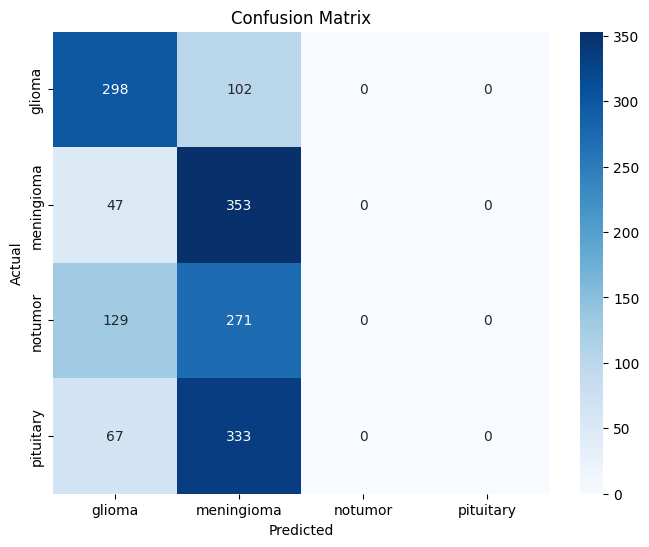

In [19]:
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


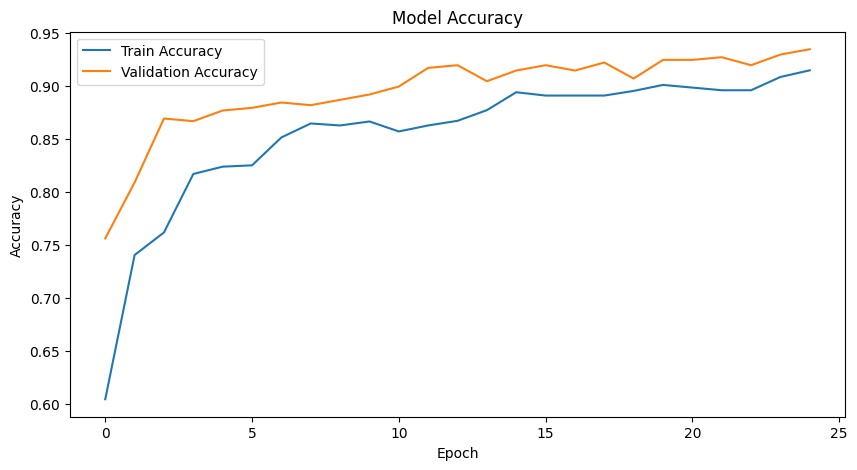

In [20]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.show()


In [21]:
model.save("brain_tumor_model.h5")

print("\nModel Saved Successfully!")



Model Saved Successfully!


In [22]:
from tensorflow.keras.preprocessing import image

img_path =  "C:/Users/Ganesh/Downloads/archive (4)/Testing/glioma/Te-gl_95.jpg"
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

predicted_class = class_labels[np.argmax(prediction)]

print("\nPredicted Class:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Predicted Class: glioma


In [23]:
pip install gradio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\Ganesh\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [1]:
import gradio as gr
import tensorflow as tf
from PIL import Image
import numpy as np

model = tf.keras.models.load_model("brain_tumor_model.h5")

def predict(image):
    image = image.resize((224, 224))
    image = np.array(image) / 255.0
    image = np.expand_dims(image, axis=0)

    prediction = model.predict(image)[0][0]

    if prediction > 0.5:
        return "Tumor Detected"
    else:
        return "No Tumor"

demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs="text"
)

demo.launch()

C:\Users\Ganesh\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [28]:
from tensorflow.keras.models import load_model
import os
print(os.path.exists(r"C:/Users/Ganesh/brain_MRI/brain_tumor_MRI.keras"))


False


In [33]:
import os
for root,dirs,files in os.walk(r"C:/Users/Ganesh"):
    for file in files:
        if file.endswith(".keras") or file.endswith(".h5"):
            print(os.path.join(root,file))

C:/Users/Ganesh\best_model.h5
C:/Users/Ganesh\best_model.keras
C:/Users/Ganesh\brain_tumor_model.h5
C:/Users/Ganesh\brain_tumor_mri_project.keras
C:/Users/Ganesh\generator_model.h5
C:/Users/Ganesh\.keras\models\mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_224_no_top.h5
C:/Users/Ganesh\AppData\Local\Programs\Python\Python311\Lib\site-packages\h5py\tests\data_files\vlen_string_dset.h5
C:/Users/Ganesh\AppData\Local\Programs\Python\Python311\Lib\site-packages\h5py\tests\data_files\vlen_string_dset_utc.h5
C:/Users/Ganesh\AppData\Local\Programs\Python\Python311\Lib\site-packages\h5py\tests\data_files\vlen_string_s390x.h5
C:/Users/Ganesh\Downloads\brain_tumor_model.h5


In [35]:
from tensorflow.keras.models import load_model
model=load_model(r"C:/Users/Ganesh/best_model.keras")
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,198,408 (27.46 MB)

 Trainable params: 2,388,098 (9.11 MB)

 Non-trainable params: 34,112 (133.25 KB)

 Optimizer params: 4,776,198 (18.22 MB)